In [41]:
from google.colab import files

uploaded = files.upload()

Saving eda_report.csv to eda_report (1).csv
Saving test_fe.csv to test_fe (1).csv
Saving train_fe.csv to train_fe (1).csv


In [42]:
!pip install -q catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.7 MB/s eta 0:00:00


In [43]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from catboost import CatBoostClassifier

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import balanced_accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
import torch

print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

CUDA Available: True
GPU: Tesla T4


In [45]:
train = pd.read_csv("train_fe.csv")
test = pd.read_csv("test_fe.csv")

sample_submission = pd.read_csv(
    "sample_submission.csv"
)

print(train.shape)
print(test.shape)

(577347, 19)
(247435, 18)


In [46]:
TARGET = "class"

X = train.drop(
    columns=["id", TARGET]
)

X_test = test.drop(
    columns=["id"]
)

y = train[TARGET]

In [47]:
le = LabelEncoder()

y_encoded = le.fit_transform(y)

print(le.classes_)

['GALAXY' 'QSO' 'STAR']


In [48]:
cat_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

cat_features

['spectral_type', 'galaxy_population']

In [49]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_preds = np.zeros(len(train))

test_probs = np.zeros(
    (len(test), 3)
)

cv_scores = []

In [50]:
for fold, (
    train_idx,
    valid_idx
) in enumerate(
    skf.split(X, y_encoded)
):

    print(
        f"\n========== Fold {fold+1} =========="
    )

    X_train = X.iloc[train_idx]
    X_valid = X.iloc[valid_idx]

    y_train = y_encoded[train_idx]
    y_valid = y_encoded[valid_idx]

    model = CatBoostClassifier(

        iterations=5000,

        learning_rate=0.03,

        depth=8,

        loss_function="MultiClass",

        eval_metric="MultiClass",

        task_type="GPU",

        devices="0",

        random_seed=42,

        verbose=200
    )

    model.fit(
        X_train,
        y_train,

        cat_features=cat_features,

        eval_set=(
            X_valid,
            y_valid
        ),

        use_best_model=True
    )

    valid_pred = model.predict(
        X_valid
    ).astype(int).flatten()

    score = balanced_accuracy_score(
        y_valid,
        valid_pred
    )

    cv_scores.append(score)

    print(
        f"Fold Score: {score:.6f}"
    )

    oof_preds[valid_idx] = valid_pred

    test_probs += (
        model.predict_proba(X_test)
        / skf.n_splits
    )


========== Fold 1 ==========
0:	learn: 1.0484168	test: 1.0483799	best: 1.0483799 (0)	total: 43ms	remaining: 3m 34s
200:	learn: 0.1219930	test: 0.1217452	best: 0.1217452 (200)	total: 4.37s	remaining: 1m 44s
400:	learn: 0.1066946	test: 0.1075257	best: 0.1075257 (400)	total: 23.3s	remaining: 4m 27s
600:	learn: 0.1005842	test: 0.1026111	best: 0.1026111 (600)	total: 27.6s	remaining: 3m 22s
800:	learn: 0.0967709	test: 0.0999722	best: 0.0999722 (800)	total: 32.2s	remaining: 2m 48s
1000:	learn: 0.0940523	test: 0.0985090	best: 0.0985084 (999)	total: 38.1s	remaining: 2m 32s
1200:	learn: 0.0917154	test: 0.0974140	best: 0.0974140 (1200)	total: 42.4s	remaining: 2m 14s
1400:	learn: 0.0898683	test: 0.0967063	best: 0.0967063 (1400)	total: 48.6s	remaining: 2m 4s
1600:	learn: 0.0881930	test: 0.0961726	best: 0.0961726 (1600)	total: 53.4s	remaining: 1m 53s
1800:	learn: 0.0866293	test: 0.0957084	best: 0.0957084 (1800)	total: 57.8s	remaining: 1m 42s
2000:	learn: 0.0851332	test: 0.0952878	best: 0.0952878 (2

In [51]:
print(
    "\nMean CV:",
    np.mean(cv_scores)
)

print(
    "Std CV:",
    np.std(cv_scores)
)


Mean CV: 0.9523260515888922
Std CV: 0.0007585253474577297


In [52]:
cv_df = pd.DataFrame({
    "fold": range(
        1,
        len(cv_scores)+1
    ),
    "score": cv_scores
})

cv_df.to_csv(
    "cv_scores.csv",
    index=False
)

cv_df

,fold,score
0,1,0.951187
1,2,0.953203
2,3,0.952268
3,4,0.953100
4,5,0.951872


In [53]:
feature_importance = pd.DataFrame({

    "feature": X.columns,

    "importance":
        model.get_feature_importance()

})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance.head(20)

,feature,importance
7,redshift,25.825553
0,alpha,11.595931
1,delta,9.910390
15,griz,9.537537
6,z,5.093387
14,ugri,4.933079
10,u_g,4.834122
12,r_i,4.465452
11,g_r,4.084413
3,g,3.780837


In [54]:
feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

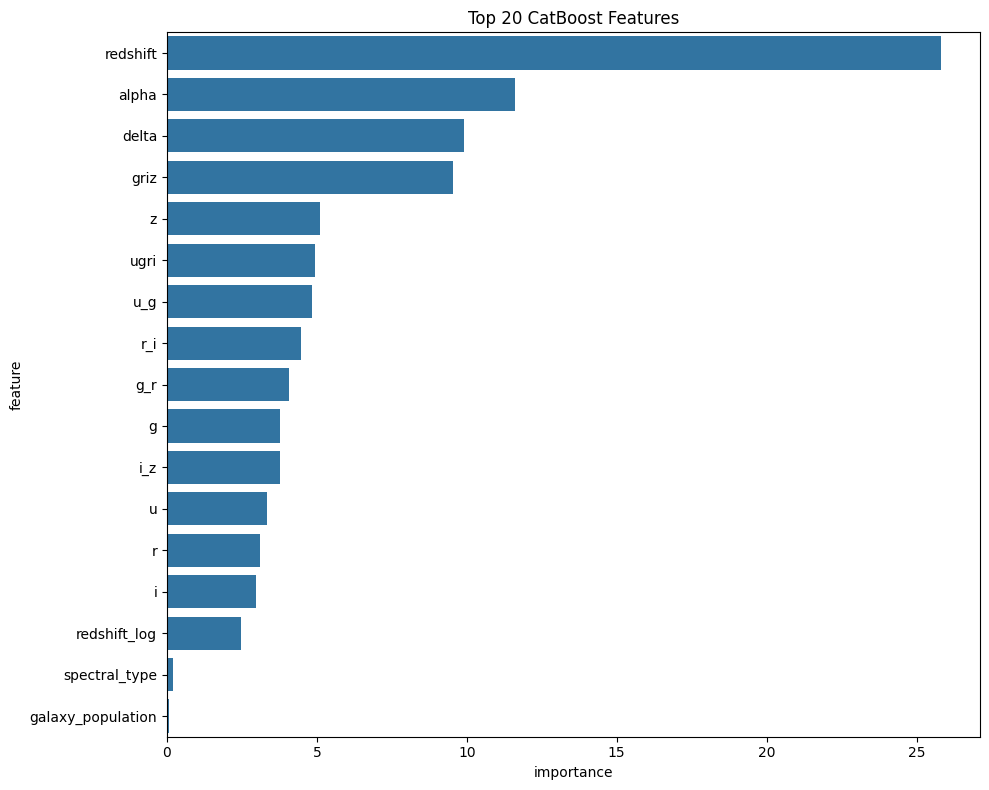

In [55]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance.head(20),
    x="importance",
    y="feature"
)

plt.title(
    "Top 20 CatBoost Features"
)

plt.tight_layout()

plt.savefig(
    "catboost_feature_importance.png",
    dpi=300
)

plt.show()

In [56]:
preds = np.argmax(
    test_probs,
    axis=1
)

submission = pd.DataFrame({

    "id": test["id"],

    "class":
        le.inverse_transform(preds)

})

submission.to_csv(
    "submission_catboost.csv",
    index=False
)

submission.head()

,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY


In [57]:
prob_df = pd.DataFrame(
    test_probs,
    columns=le.classes_
)

prob_df.insert(
    0,
    "id",
    test["id"]
)

prob_df.to_csv(
    "catboost_prob.csv",
    index=False
)

In [58]:
from google.colab import files

files.download(
    "submission_catboost.csv"
)

files.download(
    "catboost_prob.csv"
)

files.download(
    "feature_importance.csv"
)

files.download(
    "cv_scores.csv"
)

files.download(
    "catboost_feature_importance.png"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>